
# TP3 — Regresión con California Housing

Este notebook usa el dataset **California Housing** disponible en `scikit-learn`, que contiene **20.640 instancias**, **8 features numéricas** y como variable objetivo el **valor medio de las viviendas** en distritos de California, expresado en cientos de miles de dólares.

## Objetivos
1. Cargar y explorar el dataset.
2. Dividir en train/test (80/20).
3. Entrenar un modelo de **Regresión Lineal**.
4. Calcular **MSE** y **R²** en train y test.
5. Graficar **predicciones vs valores reales**.
6. Entrenar un modelo de **Regresión Polinómica de grado 2**.
7. Comparar ambos modelos.
8. Responder las preguntas finales con análisis razonado.


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


## 1) Carga y exploración del dataset

In [13]:

housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()
X = df[housing.feature_names]
y = df[housing.target_names[0]]

print("Shape del dataset:", df.shape)
print("\nFeatures:")
print(housing.feature_names)
print("\nTarget:")
print(housing.target_names)
print("\nPrimeras filas:")
display(df.head())
print("\nInformación general:")
display(df.describe())


Shape del dataset: (20640, 9)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
['MedHouseVal']

Primeras filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Información general:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2) División train/test (80/20)

In [14]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (16512, 8)
X_test : (4128, 8)
y_train: (16512,)
y_test : (4128,)


## 3) Modelo 1 — Regresión lineal

In [15]:

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_train_pred_lin = linear_model.predict(X_train)
y_test_pred_lin = linear_model.predict(X_test)

mse_train_lin = mean_squared_error(y_train, y_train_pred_lin)
mse_test_lin = mean_squared_error(y_test, y_test_pred_lin)
r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)

print("Regresión lineal")
print(f"MSE train: {mse_train_lin:.4f}")
print(f"MSE test : {mse_test_lin:.4f}")
print(f"R² train : {r2_train_lin:.4f}")
print(f"R² test  : {r2_test_lin:.4f}")


Regresión lineal
MSE train: 0.5179
MSE test : 0.5559
R² train : 0.6126
R² test  : 0.5758


## 4) Gráfico — Predicciones vs valores reales (Regresión lineal)

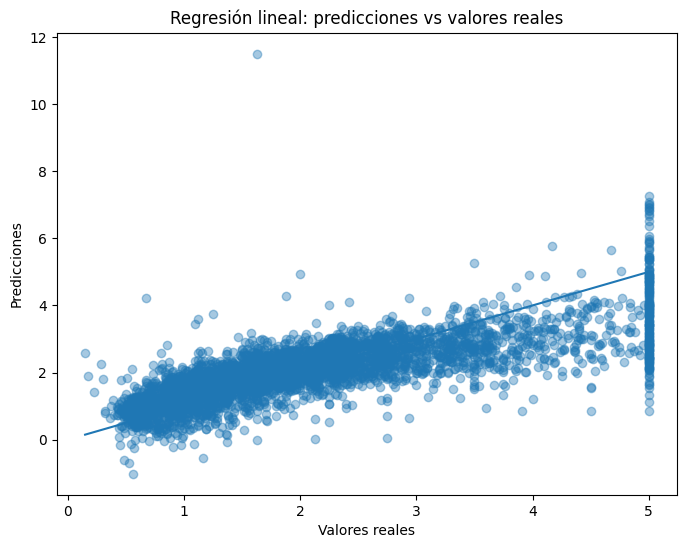

In [16]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred_lin, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión lineal: predicciones vs valores reales")
plt.show()


## 5) Modelo 2 — Regresión polinómica (grado 2)

In [17]:

poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_train_pred_poly = poly_model.predict(X_train)
y_test_pred_poly = poly_model.predict(X_test)

mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)
r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)

print("Regresión polinómica (grado 2)")
print(f"MSE train: {mse_train_poly:.4f}")
print(f"MSE test : {mse_test_poly:.4f}")
print(f"R² train : {r2_train_poly:.4f}")
print(f"R² test  : {r2_test_poly:.4f}")


Regresión polinómica (grado 2)
MSE train: 0.4207
MSE test : 0.4643
R² train : 0.6853
R² test  : 0.6457


## 6) Comparación de métricas

In [18]:

metrics_df = pd.DataFrame({
    "Modelo": ["Regresión lineal", "Regresión polinómica grado 2"],
    "MSE Train": [mse_train_lin, mse_train_poly],
    "MSE Test": [mse_test_lin, mse_test_poly],
    "R² Train": [r2_train_lin, r2_train_poly],
    "R² Test": [r2_test_lin, r2_test_poly]
})

display(metrics_df)


,Modelo,MSE Train,MSE Test,R² Train,R² Test
0,Regresión lineal,0.517933,0.555892,0.612551,0.575788
1,Regresión polinómica grado 2,0.420727,0.464302,0.685268,0.645682


## 7) Impacto de las features

In [19]:

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": linear_model.coef_,
    "Abs_Coeficiente": np.abs(linear_model.coef_)
}).sort_values("Abs_Coeficiente", ascending=False)

display(coef_df)

top_feature = coef_df.iloc[0]["Feature"]
top_coef = coef_df.iloc[0]["Coeficiente"]

print(f"La feature con mayor impacto absoluto en la regresión lineal es: {top_feature}")
print(f"Coeficiente: {top_coef:.4f}")


,Feature,Coeficiente,Abs_Coeficiente
3,AveBedrms,0.783145,0.783145
0,MedInc,0.448675,0.448675
7,Longitude,-0.433708,0.433708
6,Latitude,-0.419792,0.419792
2,AveRooms,-0.123323,0.123323
1,HouseAge,0.009724,0.009724
5,AveOccup,-0.003526,0.003526
4,Population,-0.000002,0.000002


La feature con mayor impacto absoluto en la regresión lineal es: AveBedrms
Coeficiente: 0.7831


## 8) Respuestas finales en Markdown

### ¿Cuál modelo es mejor? ¿Cómo lo determinaron?

El mejor modelo fue **Regresión polinómica grado 2**, porque obtuvo mejor desempeño en test (R²=0.6457 y MSE=0.4643) frente a la regresión lineal (R²=0.5758 y MSE=0.5559).

Lo determinamos comparando las métricas sobre el conjunto de **test**, que es el que mejor refleja la capacidad de generalización del modelo:
- Un **R² más alto** indica que el modelo explica mejor la variabilidad del precio.
- Un **MSE más bajo** indica menor error cuadrático promedio.


---


### ¿Hay señales de overfitting en alguno? ¿Cómo se dan cuenta?

Sí, hay más señales de overfitting en el modelo polinómico, porque su rendimiento en train (R²=0.6853) es mejor que en test (R²=0.6457), y esa diferencia (0.0396) es mayor que en la regresión lineal (0.0368).

El overfitting se detecta cuando un modelo rinde muy bien en **train** pero empeora en **test**, lo que sugiere que aprendió demasiado los patrones del entrenamiento y generaliza peor.


---


### ¿Qué feature tiene más impacto en el precio? ¿Cómo lo averiguaron?

La feature con mayor impacto, dentro de la **regresión lineal**, fue **AveBedrms**.

Esto se averiguó observando los **coeficientes del modelo lineal** y comparando su valor absoluto.
Cuanto mayor es el valor absoluto del coeficiente, mayor es el impacto de esa variable sobre la predicción, manteniendo constantes las demás.

En este caso, el coeficiente asociado fue **0.7831**.